In [1]:
# ============================================================
# FAKE REVIEWS DETECTOR - NLP & MACHINE LEARNING
# ============================================================
# Author: Vicente Sánchez Reza
# Date: May 2026
# Description: NLP model to detect fake customer reviews
# using text features and XGBoost classifier.
# ============================================================

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'serif'

OUTPUT_PATH = r'C:\Users\vicen\Desktop\fake-reviews-detector\outputs'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


In [4]:
df = pd.read_csv(r'C:\Users\vicen\Desktop\fake-reviews-detector\fake reviews dataset.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst rows:")
df.head()

Shape: (40432, 4)

Columns: ['category', 'rating', 'label', 'text_']

First rows:


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [5]:
print(df['label'].value_counts())

label
CG    20216
OR    20216
Name: count, dtype: int64


In [6]:
df['label_num'] = df['label'].map({'CG': 1, 'OR': 0})
print(df['label_num'].value_counts())

label_num
1    20216
0    20216
Name: count, dtype: int64


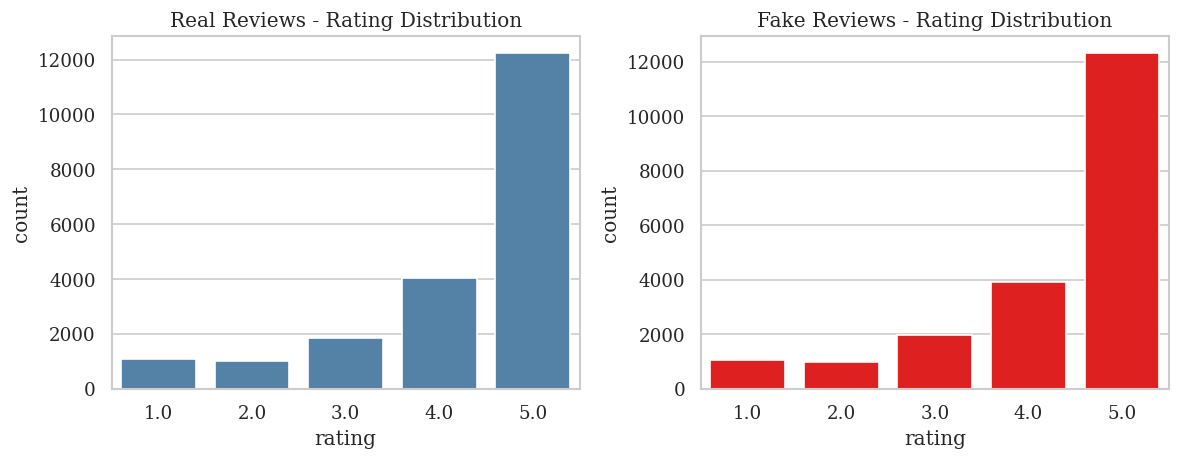

In [7]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.countplot(data=df[df['label']=='OR'], x='rating', color='steelblue')
plt.title('Real Reviews - Rating Distribution')

plt.subplot(1,2,2)
sns.countplot(data=df[df['label']=='CG'], x='rating', color='red')
plt.title('Fake Reviews - Rating Distribution')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}\\01_rating_distribution.png')
plt.show()

In [8]:
# ── TEXT LENGTH ANALYSIS ──────────────────────────────────────
# Do fake reviews tend to be shorter or longer than real ones?

df['text_length'] = df['text_'].apply(len)

print(df.groupby('label')['text_length'].describe())

         count        mean         std   min    25%    50%    75%     max
label                                                                    
CG     20216.0  305.573506  307.037430  24.0   96.0  174.0  383.0  1717.0
OR     20216.0  396.970419  418.428047  28.0  121.0  224.0  498.0  2827.0


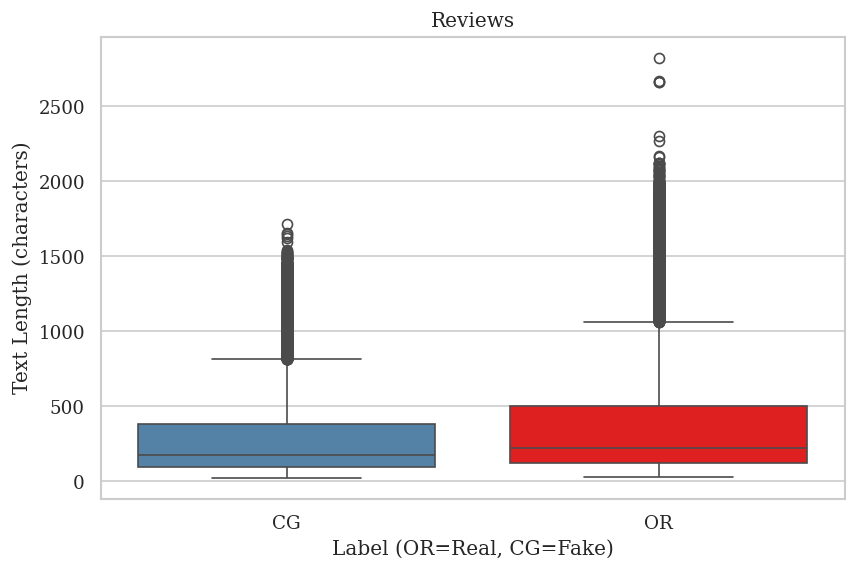

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label', y='text_length', hue='label', palette=['steelblue', 'red'], legend=False)
plt.title('Reviews')
plt.xlabel('Label (OR=Real, CG=Fake)')
plt.ylabel('Text Length (characters)')
plt.savefig(f'{OUTPUT_PATH}\\02_text_length.png')
plt.show()

In [11]:
# ── PREPARE DATA ─────────────────────────────────────────────
X = df['text_']        # texto de la reseña
y = df['label_num']        # label numérico (0 o 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples:  {len(X_test):,}")

Training samples: 32,345
Testing samples:  8,087


In [12]:
# ── TF-IDF VECTORIZATION ──────────────────────────────────────
# Converts text into numbers the model can understand
# max_features=10000 means we use the 10,000 most important words

vectorizer = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1,2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Training matrix shape: {X_train_tfidf.shape}")
print("Text vectorized successfully ✅")

Training matrix shape: (32345, 10000)
Text vectorized successfully ✅


In [13]:
# ── TRAIN XGBOOST MODEL ───────────────────────────────────────
# XGBoost is a powerful gradient boosting algorithm

model_xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')

model_xgb.fit(X_train_tfidf, y_train)

y_pred = model_xgb.predict(X_test_tfidf)

print("XGBoost trained successfully ✅")

XGBoost trained successfully ✅


In [15]:
# ── MODEL EVALUATION ─────────────────────────────────────────
print("=== XGBOOST RESULTS ===\n")
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred):.4f}")

=== XGBOOST RESULTS ===

              precision    recall  f1-score   support

        Real       0.81      0.88      0.85      4071
        Fake       0.87      0.79      0.83      4016

    accuracy                           0.84      8087
   macro avg       0.84      0.84      0.84      8087
weighted avg       0.84      0.84      0.84      8087

ROC-AUC Score: 0.8373


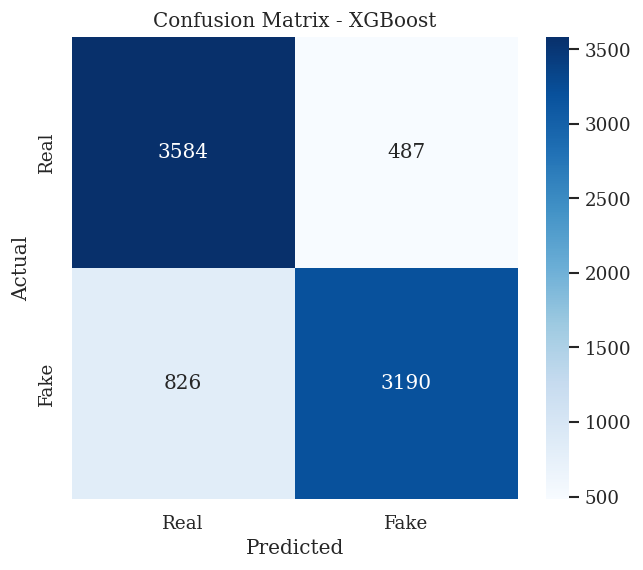

In [16]:
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig(f'{OUTPUT_PATH}\\03_confusion_matrix.png')
plt.show()